In [1]:
!pip install kaggle


In [5]:
#using kagle
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download krishuppal/helmet-detection

Dataset URL: https://www.kaggle.com/datasets/krishuppal/helmet-detection
License(s): apache-2.0
 85% 332M/391M [00:00<00:00, 725MB/s]
100% 391M/391M [00:00<00:00, 615MB/s]


In [7]:
!unzip -q /content/helmet-detection.zip -d ./dataset

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
import seaborn as sns



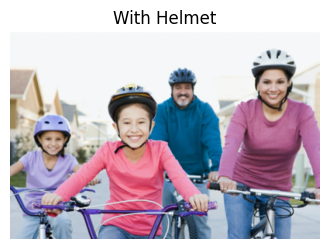

In [9]:
plt.figure(figsize=(4,4))
filepath="/content/dataset/helmet detection dataset/With Helmet/BikesHelmets0.png"
image=imread(filepath)
plt.imshow(image)
plt.title('With Helmet',fontsize=12)
plt.axis('off')
plt.show()

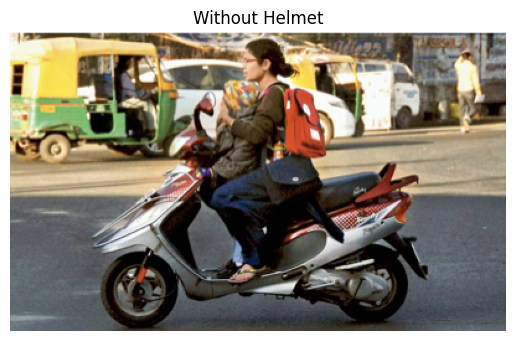

In [10]:
filepath="/content/dataset/helmet detection dataset/Without Helmet/BikesHelmets10.png"
image = imread(filepath)
plt.imshow(image)
plt.title('Without Helmet',fontsize=12)
plt.axis('off')
plt.show()

In [11]:
import os
import shutil
from pathlib import Path

base_dir=Path("/content/dataset")
train_dir="/content/dataset/train"
val_dir="/content/dataset/val"

os.makedirs(train_dir,exist_ok=True)
os.makedirs(val_dir,exist_ok=True)

In [12]:
#move files (80% train, 20% validation)
for category in ['With Helmet','Without Helmet']:
  os.makedirs(f'{train_dir}/{category}',exist_ok=True)
  os.makedirs(f'{val_dir}/{category}',exist_ok=True)

  images=list((base_dir/"helmet detection dataset"/ category).glob("*.*"))
  split=int(0.8 * len(images))

  for img in images[:split]:
    shutil.move(str(img),f"{train_dir}/{category}")

  for img in images[split:]:
    shutil.move(str(img),f"{val_dir}/{category}")

print("Dataset organized into training and validation sets.")

Dataset organized into training and validation sets.


In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [14]:
# Data Preprocessing
# Define image size and batch size
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Create ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1.0/255,  # Normalize pixel values
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1.0/255)  # Only rescaling

# Load images from directory
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

Found 611 images belonging to 2 classes.
Found 153 images belonging to 2 classes.


In [15]:
# Build CNN model
# ResNet152V2

base_model = tf.keras.applications.ResNet152V2(include_top=False, weights="imagenet", input_shape=(128,128,3), classifier_activation='sigmoid')

# Freeze convolutional base for feature extraction
base_model.trainable = False

234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

model.add(base_model)
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(256,activation='relu'))
model.add(Dropout(rate=0.2))
model.add(Dense(1,activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    train_data,
    epochs=8,
    validation_data=val_data
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.5620 - loss: 2.1057 - val_accuracy: 0.7320 - val_loss: 3.8720
Epoch 2/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 678ms/step - accuracy: 0.7057 - loss: 1.9708 - val_accuracy: 0.6144 - val_loss: 3.0508
Epoch 3/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 682ms/step - accuracy: 0.7532 - loss: 1.0433 - val_accuracy: 0.6536 - val_loss: 2.8042
Epoch 4/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 672ms/step - accuracy: 0.7829 - loss: 0.6099 - val_accuracy: 0.6471 - val_loss: 2.0885
Epoch 5/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 686ms/step - accuracy: 0.7760 - loss: 0.5104 - val_accuracy: 0.6732 - val_loss: 1.6989
Epoch 6/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 665ms/step - accuracy: 0.8258 - loss: 0.4479 - val_accuracy: 0.7124 - val_loss: 1.3784
Epoch 7/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 663ms/step - accuracy: 0.8278 - loss: 0.4382 - val_accuracy: 0.6601 - val_loss: 1.3034
Epoch 8/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 693ms/step - accuracy: 0.8324 - loss: 0.4133 - val_accuracy: 0.686

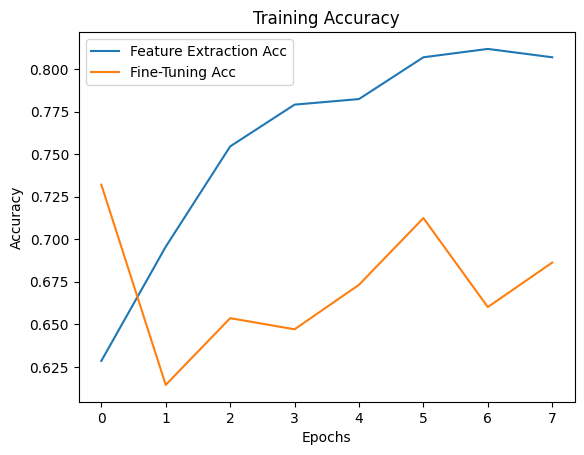

In [20]:
# Plot Training Results
plt.plot(history.history['accuracy'], label='Feature Extraction Acc')
plt.plot(history.history['val_accuracy'], label='Fine-Tuning Acc')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()

In [21]:
model.save("Helmet_Classifier_ResNet152V2_V4.h5")
print("Model saved successfully!")

Model saved successfully!


In [22]:
# Evaluate on Validation Data
val_loss, val_acc = model.evaluate(val_data)
print(f"Validation Accuracy: {val_acc:.2f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 424ms/step - accuracy: 0.7040 - loss: 1.3710
Validation Accuracy: 0.69


In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = []
y_pred = []
steps = len(val_data)  # Number of batches
for _ in range(steps):
    x, y = next(val_data)  # Get one batch
    pred_probs = model.predict(x, verbose=0)
    pred_labels = (pred_probs > 0.5).astype(int).flatten()

    # Store correct labels and predictions
    y_true.extend(y.flatten().tolist())
    y_pred.extend(pred_labels.tolist())

# Convert to NumPy arrays
y_true = np.array(y_true, dtype='int')
y_pred = np.array(y_pred, dtype='int')

# Step 3: Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

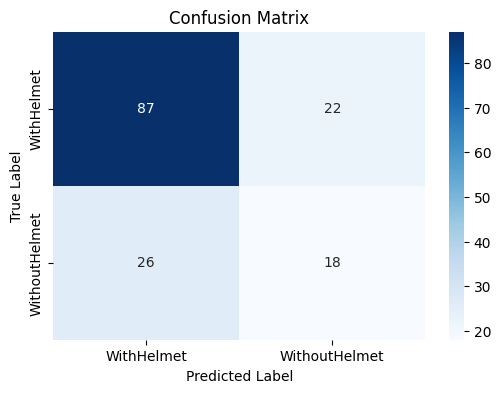

In [24]:
# Step 4: Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['WithHelmet', 'WithoutHelmet'], yticklabels=['WithHelmet', 'WithoutHelmet'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [26]:
report = classification_report(y_true, y_pred, target_names=['WithHelmet', 'WithoutHelmet'])
print(report)

               precision    recall  f1-score   support

   WithHelmet       0.77      0.80      0.78       109
WithoutHelmet       0.45      0.41      0.43        44

     accuracy                           0.69       153
    macro avg       0.61      0.60      0.61       153
 weighted avg       0.68      0.69      0.68       153



In [28]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)  # Changed line
    img_array = tf.keras.utils.img_to_array(img) / 255.0  # Normalize # Changed line
    img_array = np.expand_dims(img_array, axis=0)  # Reshape for model

    prediction = model.predict(img_array)[0][0]
    print(prediction)
    label = "WithoutHelmet" if prediction > 0.5 else "WithHelmet"

    print(f"Prediction: {label} (Confidence: {prediction:.2f})")

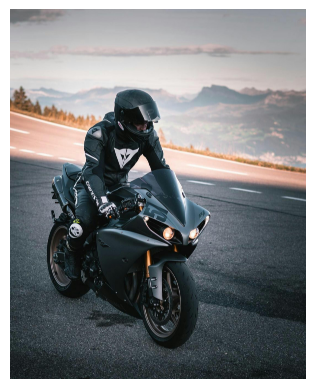

In [35]:
img_path ="withhelmet.jpeg"
image =imread(img_path)
plt.imshow(image)
plt.axis('off')
plt.show()

In [36]:
predict_image(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
0.0052205687
Prediction: WithHelmet (Confidence: 0.01)


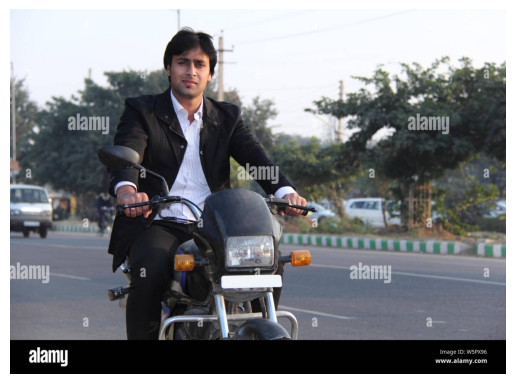

In [37]:
img_path2 ="withouthelmet.jpeg"
image2 =imread(img_path2)
plt.imshow(image2)
plt.axis('off')
plt.show()

In [38]:
predict_image(img_path2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
0.2616117
Prediction: WithHelmet (Confidence: 0.26)
